STOCK MARKET PREDICTION USING LASSO REGRESSION 
(Shivani Patel, Faizan Abbas)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn import metrics
import matplotlib.pyplot as plt

In [3]:
# Reading the Excel file into a DataFrame
dataset = pd.read_excel(r'C:\Users\shivani\Downloads\yahoo_data.xlsx')


In [4]:
# Displaying the first few rows of the dataset
print(dataset.head())


           Date      Open      High       Low    Close*  Adj Close**  \
0  Apr 28, 2023  33797.43  34104.56  33728.40  34098.16     34098.16   
1  Apr 27, 2023  33381.66  33859.75  33374.65  33826.16     33826.16   
2  Apr 26, 2023  33596.34  33645.83  33235.85  33301.87     33301.87   
3  Apr 25, 2023  33828.34  33875.49  33525.39  33530.83     33530.83   
4  Apr 24, 2023  33805.04  33891.15  33726.09  33875.40     33875.40   

      Volume  
0  354310000  
1  343240000  
2  321170000  
3  297880000  
4  252020000  


In [5]:
# Displaying the data types of the columns
print(dataset.dtypes)

Date            object
Open           float64
High           float64
Low            float64
Close*         float64
Adj Close**    float64
Volume           int64
dtype: object


In [6]:
# Convert 'Date' column to datetime format
dataset['Date'] = pd.to_datetime(dataset['Date'])

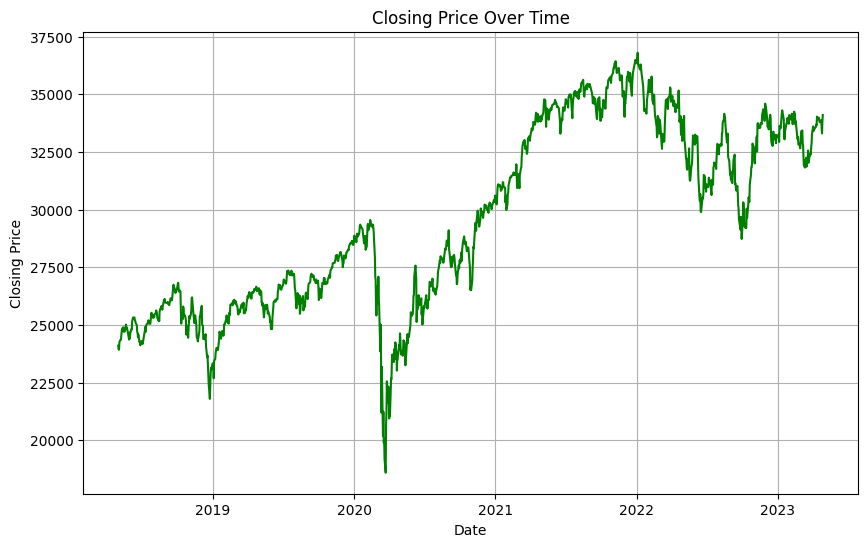

In [18]:
# Plotting the closing price of the asset over time
plt.figure(figsize=(10, 6))
plt.plot(dataset['Date'], dataset['Close*'], color='green')  # Using 'Close*' column
plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

In [8]:
# Feature selection
features = ['Open', 'High', 'Low', 'Volume']
target = 'Close*'

In [20]:
# Calculate the Pearson correlation coefficient between features and target
corr_matrix = dataset[features + [target]].corr()

# Print the correlation matrix
print(corr_matrix)

# Extract the Pearson correlation coefficient between Open and Close*
open_close_corr = corr_matrix.loc['Open', 'Close*']
print("Pearson correlation coefficient between Open and Close*:", open_close_corr)

# Extract the Pearson correlation coefficient between High and Close*
high_close_corr = corr_matrix.loc['High', 'Close*']
print("Pearson correlation coefficient between High and Close*:", high_close_corr)

# Extract the Pearson correlation coefficient between Low and Close*
low_close_corr = corr_matrix.loc['Low', 'Close*']
print("Pearson correlation coefficient between Low and Close*:", low_close_corr)

# Extract the Pearson correlation coefficient between Volume and Close*
volume_close_corr = corr_matrix.loc['Volume', 'Close*']
print("Pearson correlation coefficient between Volume and Close*:", volume_close_corr)

            Open      High       Low    Volume    Close*
Open    1.000000  0.999043  0.998626 -0.088002  0.997592
High    0.999043  1.000000  0.998198 -0.073388  0.998682
Low     0.998626  0.998198  1.000000 -0.115077  0.998839
Volume -0.088002 -0.073388 -0.115077  1.000000 -0.096766
Close*  0.997592  0.998682  0.998839 -0.096766  1.000000
Pearson correlation coefficient between Open and Close*: 0.9975918949260207
Pearson correlation coefficient between High and Close*: 0.9986818009207821
Pearson correlation coefficient between Low and Close*: 0.998838884115813
Pearson correlation coefficient between Volume and Close*: -0.09676592501687567


In [10]:
# Splitting the dataset into features (X) and target (y)
X = dataset[features]
y = dataset[target]

In [11]:
# Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
# Initializing and training the Lasso regression model
model = Lasso(alpha=0.1,max_iter=10000)  # Increasing max_iter to help convergence
model.fit(X_train, y_train)

Lasso(alpha=0.1, max_iter=10000)

In [13]:
# Making predictions
y_pred = model.predict(X_test)

In [14]:
# Evaluating the model
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)


In [15]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R^2 Score:", r2)

Mean Absolute Error: 83.76586363455353
Mean Squared Error: 13312.730627724835
Root Mean Squared Error: 115.38080701626608
R^2 Score: 0.9991791822045816


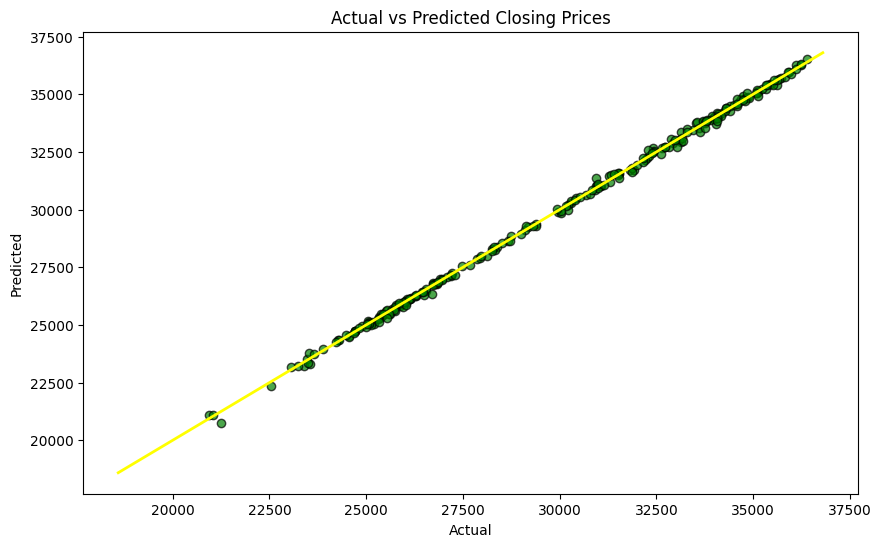

In [19]:
# Plotting the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='green', edgecolors='k', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='yellow', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Closing Prices')
plt.show()